# 01_project_setup
Thiết lập môi trường và cấu hình chung cho nghiên cứu sâu về mất cân bằng lớp (Deep Imbalance Analysis) sử dụng mô hình SimpleCNN huấn luyện từ đầu.
Chúng ta cấu hình SEED ngẫu nhiên cố định để đảm bảo khả năng tái lập kết quả.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

def bootstrap_project_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidates = [root, root / 'plan']
        for candidate in candidates:
            if (candidate / 'src').exists():
                if str(candidate) not in sys.path:
                    sys.path.append(str(candidate))
                from src.paths import find_project_dir
                return find_project_dir(candidate)
    raise FileNotFoundError('Không tìm thấy thư mục project plan chứa src/. Hãy chạy notebook từ repo hoặc thư mục plan.')


PROJECT_DIR = bootstrap_project_dir()

from src.data import (
    ProjectPaths,
    ensure_directories,
    load_metadata,
    create_imbalanced_subset,
    create_stratified_subset,
    create_hybrid_resampled_dataset,
    get_num_classes,
    compute_inverse_frequency_weights,
    build_data_loader,
    build_weighted_sampler,
)
from src.models import get_simple_cnn
from src.train import train_model, evaluate_model
from src.utils import (
    set_seed,
    get_device,
    get_pin_memory,
    get_num_workers,
    get_basic_transform,
    get_light_augmentation_transform,
    dataframe_to_markdown_safe,
)
from src.visualization import set_publication_style, plot_learning_curves, annotate_bars

SEED = 42
set_seed(SEED)
set_publication_style()

DEVICE = get_device()
print(f"Thiết bị sử dụng: {DEVICE}")

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_DIR = PATHS.results_dir('05_imbalance_analysis')
REPORTS_DIR = PATHS.reports_dir('05_imbalance_analysis')

ensure_directories(
    RESULTS_DIR,
    REPORTS_DIR,
    RESULTS_DIR / 'saved_models',
    RESULTS_DIR / 'gradcam_visualizations',
)

# Giữ subset mode để thí nghiệm mất cân bằng chạy nhanh nhưng vẫn đủ lớn.
USE_SUBSET = True

# Cấu hình subset có chủ đích:
# - Majority classes lấy tỷ lệ nhỏ hơn.
# - Minority classes giữ tỷ lệ lớn hơn để không quá ít mẫu.
SUBSET_MAJORITY_FRACTION = 0.20
SUBSET_MINORITY_FRACTION = 0.45
SUBSET_THRESHOLD = 500
SUBSET_MIN_SAMPLES = 40
VAL_TEST_SUBSET_FRACTION = 0.30
VAL_TEST_MIN_SAMPLES = 8

IMAGE_SIZE = 128
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)

FORCE_TRAIN = True
EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
BATCH_SIZE = 64
LR = 1e-3




Thiết bị sử dụng: mps


# 02_load_color_dataset
Nạp các tệp metadata (`train.csv`, `val.csv`, `test.csv`) của COLOR dataset.

Notebook đang bật `USE_SUBSET=True` để chạy nhanh khi so sánh các kỹ thuật xử lý mất cân bằng. Subset hiện tại là preset thực nghiệm nhanh:

- Lớp đa số giữ khoảng 20% mẫu.
- Lớp thiểu số giữ khoảng 45% mẫu.
- Mỗi lớp có tối thiểu 40 ảnh nếu dữ liệu gốc cho phép.
- Val/test lấy stratified subset 30%.
- Ảnh resize về `128×128` để giảm thời gian huấn luyện.

Mục tiêu là giữ bài toán vẫn imbalance, nhưng training đủ nhanh để so sánh nhiều phương án.


In [2]:
train_df_raw, val_df_raw, test_df_raw, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)

print('Raw metadata size:')
print(f'  Train: {len(train_df_raw):,} images')
print(f'  Val  : {len(val_df_raw):,} images')
print(f'  Test : {len(test_df_raw):,} images')
print(f'  Classes: {NUM_CLASSES}')

if USE_SUBSET:
    train_df = create_imbalanced_subset(
        train_df_raw,
        majority_fraction=SUBSET_MAJORITY_FRACTION,
        minority_fraction=SUBSET_MINORITY_FRACTION,
        threshold=SUBSET_THRESHOLD,
        min_samples=SUBSET_MIN_SAMPLES,
        seed=SEED,
    )
    val_df = create_stratified_subset(
        val_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
    test_df = create_stratified_subset(
        test_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
    print('[SUBSET MODE] Dùng subset có kiểm soát để thí nghiệm nhanh hơn.')
else:
    train_df = train_df_raw.copy()
    val_df = val_df_raw.copy()
    test_df = test_df_raw.copy()
    print('[FULL DATA MODE] Dùng đầy đủ train/val/test split.')

print('Active data size used by this notebook:')
print(f'  Train: {len(train_df):,} images')
print(f'  Val  : {len(val_df):,} images')
print(f'  Test : {len(test_df):,} images')
print(f'Image size used for training: {IMAGE_SIZE}x{IMAGE_SIZE}')

class_names_list = class_map_df.sort_values('class_id')['class_name'].tolist()
test_labels = test_df['class_id'].values

baseline_transform = get_basic_transform(IMAGE_SIZE)
train_transform_plain = baseline_transform
val_test_transform = baseline_transform
train_transform_light_aug = get_light_augmentation_transform(IMAGE_SIZE)



Raw metadata size:
  Train: 43,444 images
  Val  : 5,430 images
  Test : 5,431 images
  Classes: 38
[SUBSET MODE] Dùng subset có kiểm soát để thí nghiệm nhanh hơn.
Active data size used by this notebook:
  Train: 9,383 images
  Val  : 1,617 images
  Test : 1,618 images
Image size used for training: 128x128


# 03_class_distribution_analysis
Phân tích phân phối số lượng mẫu của từng lớp trên tập huấn luyện thực tế và highlight các lớp đa số và thiểu số.
Biểu đồ barplot trực quan hóa tỷ lệ mất cân bằng nghiêm trọng này.


Imbalance Ratio tập huấn luyện: 16.31

--- Top 5 Lớp Đa số (Majority Classes) ---


,class_id,class_name,sample_count
0,15,Orange___Haunglongbing_(Citrus_greening),881
1,35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,857
2,24,Soybean___healthy,814
3,16,Peach___Bacterial_spot,367
4,28,Tomato___Bacterial_spot,340



--- Top 5 Lớp Thiểu số (Minority Classes) ---


,class_id,class_name,sample_count
33,23,Raspberry___healthy,133
34,17,Peach___healthy,129
35,0,Apple___Apple_scab,100
36,2,Apple___Cedar_apple_rust,99
37,22,Potato___healthy,54


/var/folders/dv/944l43vs4k316f2j10f81lyh0000gp/T/ipykernel_72938/3622604581.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x='class_id', y='sample_count', palette='viridis')


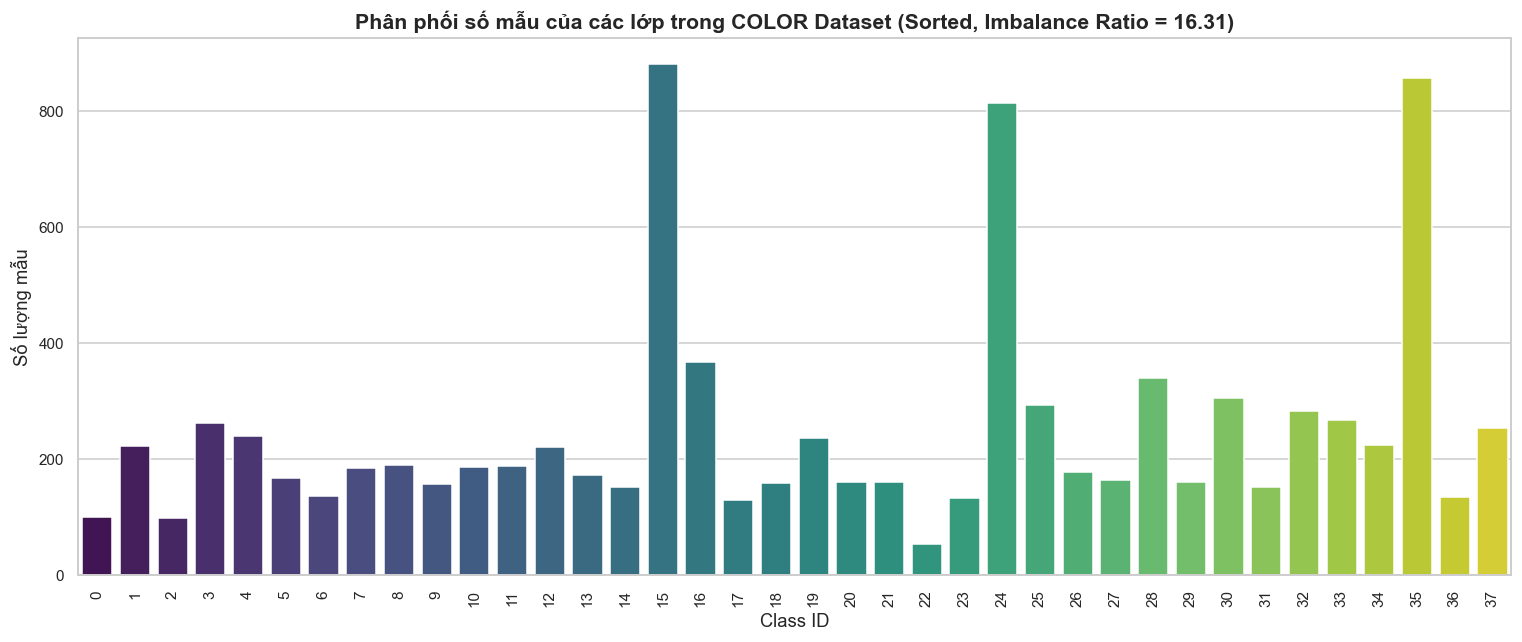

In [3]:
train_counts = train_df['class_id'].value_counts().sort_index()
imbalance_ratio = train_counts.max() / train_counts.min()

dist_df = pd.DataFrame({
    'class_id': train_counts.index,
    'class_name': [class_names_list[idx] for idx in train_counts.index],
    'sample_count': train_counts.values
}).sort_values(by='sample_count', ascending=False).reset_index(drop=True)

top_5_majority = dist_df.head(5)
top_5_minority = dist_df.tail(5)

print(f"Imbalance Ratio tập huấn luyện: {imbalance_ratio:.2f}")
print("\n--- Top 5 Lớp Đa số (Majority Classes) ---")
display(top_5_majority)
print("\n--- Top 5 Lớp Thiểu số (Minority Classes) ---")
display(top_5_minority)

plt.figure(figsize=(14, 6))
sns.barplot(data=dist_df, x='class_id', y='sample_count', palette='viridis')
plt.title(f'Phân phối số mẫu của các lớp trong COLOR Dataset (Sorted, Imbalance Ratio = {imbalance_ratio:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution_chart.png', dpi=300)
plt.show()


# 04_imbalance_handling_components
Phần này tập trung vào `WeightedRandomSampler` như chiến lược chính để xử lý mất cân bằng lớp.

`WeightedRandomSampler` là một **dynamic oversampling strategy**:

- Không tạo ảnh mới trên đĩa.
- Không thay đổi dataframe gốc.
- Chỉ tăng xác suất minority samples xuất hiện trong mini-batch / epoch.

Ưu điểm: minority classes được nhìn thấy nhiều hơn trong quá trình huấn luyện, giúp cải thiện Macro F1 và Minority Recall.

Nhược điểm: minority samples có thể bị lặp lại nhiều lần. Nếu không có augmentation và early stopping, mô hình dễ memorize các ảnh thiểu số thay vì học đặc trưng bệnh học tổng quát.


In [4]:
class_sample_weights = compute_inverse_frequency_weights(
    class_counts=train_counts,
    num_classes=NUM_CLASSES,
)

# Tensor version dùng cho weighted loss hoặc loss study ở phase sau.
class_weights = torch.FloatTensor(class_sample_weights).to(DEVICE)

weight_table = pd.DataFrame({
    'class_id': range(NUM_CLASSES),
    'class_name': class_names_list,
    'train_count': [int(train_counts.get(class_id, 0)) for class_id in range(NUM_CLASSES)],
    'sampler_weight': class_sample_weights,
})

display(weight_table.sort_values('sampler_weight', ascending=False).head(10))



,class_id,class_name,train_count,sampler_weight
22,22,Potato___healthy,54,3.335891
2,2,Apple___Cedar_apple_rust,99,1.819577
0,0,Apple___Apple_scab,100,1.801381
17,17,Peach___healthy,129,1.396419
23,23,Raspberry___healthy,133,1.354422
36,36,Tomato___Tomato_mosaic_virus,134,1.344314
6,6,Cherry_(including_sour)___healthy,136,1.324545
14,14,Grape___healthy,152,1.185119
31,31,Tomato___Leaf_Mold,152,1.185119
9,9,Corn_(maize)___Northern_Leaf_Blight,157,1.147376


# 05_model_training_and_evaluation_helpers
Định nghĩa SimpleCNN, hàm huấn luyện có tùy chọn EarlyStopping dựa trên Validation Macro F1, và hàm đánh giá trên test set.

EarlyStopping cần thiết vì WeightedRandomSampler có thể làm train loss giảm nhanh do lặp lại minority samples, nhưng validation Macro F1 không cải thiện tương ứng. Khi đó tiếp tục train sẽ tăng nguy cơ overfitting minority classes.


In [5]:
# Các helper huấn luyện và đánh giá được dùng chung từ src:
# - get_simple_cnn: kiến trúc SimpleCNN thống nhất.
# - train_model: train theo Validation Macro F1 và hỗ trợ EarlyStopping.
# - evaluate_model: trả về Accuracy, Macro Precision/Recall/F1 và per-class metrics.

print('Đã nạp helper dùng chung: get_simple_cnn, train_model, evaluate_model')



Đã nạp helper dùng chung: get_simple_cnn, train_model, evaluate_model


# 06_weighted_sampler_overfitting_experiments
Phase 5 tập trung vào một câu hỏi chính:

> WeightedRandomSampler cải thiện minority exposure, nhưng làm sao giảm overfitting do minority samples bị lặp lại quá nhiều?

Notebook so sánh 5 cấu hình gọn:

1. `baseline`: uniform sampling, no augmentation.
2. `weighted_sampler`: dynamic oversampling bằng WeightedRandomSampler.
3. `sampler_light_aug`: WeightedRandomSampler + light data augmentation.
4. `sampler_aug_earlystop`: WeightedRandomSampler + light augmentation + EarlyStopping.
5. `hybrid_resampling`: cân bằng dữ liệu bằng undersampling + oversampling để làm đối chứng data-level.

Các nhánh focal loss, mixup, sampler+focal được bỏ khỏi luồng chính để phase này clean hơn và tập trung đúng giả thuyết overfitting của sampler.


In [6]:
experiments_results = {}
training_histories = {}


def build_phase05_loaders(train_data, train_transform, use_sampler=False):
    """Tạo train/validation loaders cho một experiment Phase 05."""
    sampler = None
    if use_sampler:
        sampler = build_weighted_sampler(train_data, class_sample_weights, replacement=True)

    train_loader = build_data_loader(
        df=train_data,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=train_transform,
        batch_size=BATCH_SIZE,
        shuffle=not use_sampler,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(
        df=val_df,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=val_test_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader


def load_or_train_experiment(
    exp_name,
    filename,
    train_transform,
    use_sampler=False,
    use_early_stopping=False,
    override_train_df=None,
    epochs=EPOCHS,
):
    """Train hoặc load một experiment mất cân bằng, sau đó evaluate trên test set."""
    save_path = RESULTS_DIR / 'saved_models' / filename
    train_data = override_train_df if override_train_df is not None else train_df

    model = get_simple_cnn(num_classes=NUM_CLASSES).to(DEVICE)
    history = None
    loaded = False

    if not FORCE_TRAIN and save_path.exists():
        try:
            model.load_state_dict(torch.load(save_path, map_location=DEVICE))
            print(f'Đã nạp thành công mô hình {exp_name} từ {save_path}')
            loaded = True
        except Exception as error:
            print(f'Cảnh báo: Không thể nạp checkpoint {exp_name}: {error}')

    if not loaded:
        print(f'\n--- Bắt đầu huấn luyện mô hình: {exp_name} ---')
        print(f'Train size used: {len(train_data):,} images')
        print(f'WeightedRandomSampler: {use_sampler} | EarlyStopping: {use_early_stopping}')

        train_loader, val_loader = build_phase05_loaders(
            train_data=train_data,
            train_transform=train_transform,
            use_sampler=use_sampler,
        )
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=LR)

        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            epochs=epochs,
            device=DEVICE,
            save_path=save_path,
            patience=EARLY_STOPPING_PATIENCE,
            use_early_stopping=use_early_stopping,
        )
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))

    test_loader = build_data_loader(
        df=test_df,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=baseline_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    eval_res = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)

    experiments_results[exp_name] = eval_res
    if history is not None:
        training_histories[exp_name] = history

    print(f"[RESULT {exp_name.upper()}] Acc: {eval_res['accuracy']:.4f} | Macro F1: {eval_res['macro_f1']:.4f}")
    return eval_res


# Hybrid Resampling được giữ lại làm baseline data-level để so sánh.
HYBRID_TARGET_SIZE = int(train_df['class_id'].value_counts().median())
hybrid_train_df = create_hybrid_resampled_dataset(train_df, target_size=HYBRID_TARGET_SIZE, seed=SEED)
print(
    f'Quy mô tập train sau khi Hybrid Resampling: {len(hybrid_train_df):,} '
    f'(Mỗi lớp có đúng {HYBRID_TARGET_SIZE:,} mẫu)'
)

EXPERIMENT_CONFIGS = [
    {
        'name': 'baseline',
        'filename': f'baseline_{IMAGE_SIZE}px_best.pth',
        'train_transform': train_transform_plain,
        'use_sampler': False,
        'use_early_stopping': False,
    },
    {
        'name': 'weighted_sampler',
        'filename': f'weighted_sampler_{IMAGE_SIZE}px_best.pth',
        'train_transform': train_transform_plain,
        'use_sampler': True,
        'use_early_stopping': False,
    },
    {
        'name': 'sampler_light_aug',
        'filename': f'sampler_light_aug_{IMAGE_SIZE}px_best.pth',
        'train_transform': train_transform_light_aug,
        'use_sampler': True,
        'use_early_stopping': False,
    },
    {
        'name': 'sampler_aug_earlystop',
        'filename': f'sampler_aug_earlystop_{IMAGE_SIZE}px_best.pth',
        'train_transform': train_transform_light_aug,
        'use_sampler': True,
        'use_early_stopping': True,
    },
    {
        'name': 'hybrid_resampling',
        'filename': f'hybrid_resampling_{IMAGE_SIZE}px_best.pth',
        'train_transform': train_transform_light_aug,
        'use_sampler': False,
        'use_early_stopping': True,
        'override_train_df': hybrid_train_df,
    },
]

for config in EXPERIMENT_CONFIGS:
    load_or_train_experiment(
        exp_name=config['name'],
        filename=config['filename'],
        train_transform=config['train_transform'],
        use_sampler=config.get('use_sampler', False),
        use_early_stopping=config.get('use_early_stopping', False),
        override_train_df=config.get('override_train_df'),
    )



Quy mô tập train sau khi Hybrid Resampling: 7,030 (Mỗi lớp có đúng 185 mẫu)

--- Bắt đầu huấn luyện mô hình: baseline ---
Train size used: 9,383 images
WeightedRandomSampler: False | EarlyStopping: False
Epoch 01/15 | Train Loss: 2.6598 | Val Loss: 1.8938 | Val Acc: 0.4873 | Val Macro F1: 0.2310
Epoch 02/15 | Train Loss: 1.7599 | Val Loss: 1.4066 | Val Acc: 0.5628 | Val Macro F1: 0.4030
Epoch 03/15 | Train Loss: 1.4064 | Val Loss: 1.1750 | Val Acc: 0.6475 | Val Macro F1: 0.5182
Epoch 04/15 | Train Loss: 1.1957 | Val Loss: 0.9531 | Val Acc: 0.7174 | Val Macro F1: 0.6262
Epoch 05/15 | Train Loss: 1.0625 | Val Loss: 0.8411 | Val Acc: 0.7594 | Val Macro F1: 0.6858
Epoch 06/15 | Train Loss: 0.9577 | Val Loss: 0.8433 | Val Acc: 0.7390 | Val Macro F1: 0.6599
Epoch 07/15 | Train Loss: 0.8717 | Val Loss: 0.7443 | Val Acc: 0.7669 | Val Macro F1: 0.7086
Epoch 08/15 | Train Loss: 0.7980 | Val Loss: 0.7505 | Val Acc: 0.7681 | Val Macro F1: 0.7169
Epoch 09/15 | Train Loss: 0.7356 | Val Loss: 0.6069 

# 07_training_curves_overfitting_check
Vẽ training curves để theo dõi overfitting.

Dấu hiệu overfitting thường gặp:

- Train loss tiếp tục giảm.
- Validation loss không giảm hoặc tăng.
- Validation Macro F1 đứng yên hoặc giảm.

Với WeightedRandomSampler, dấu hiệu này đặc biệt quan trọng vì minority samples có thể bị lặp lại nhiều lần trong mỗi epoch.


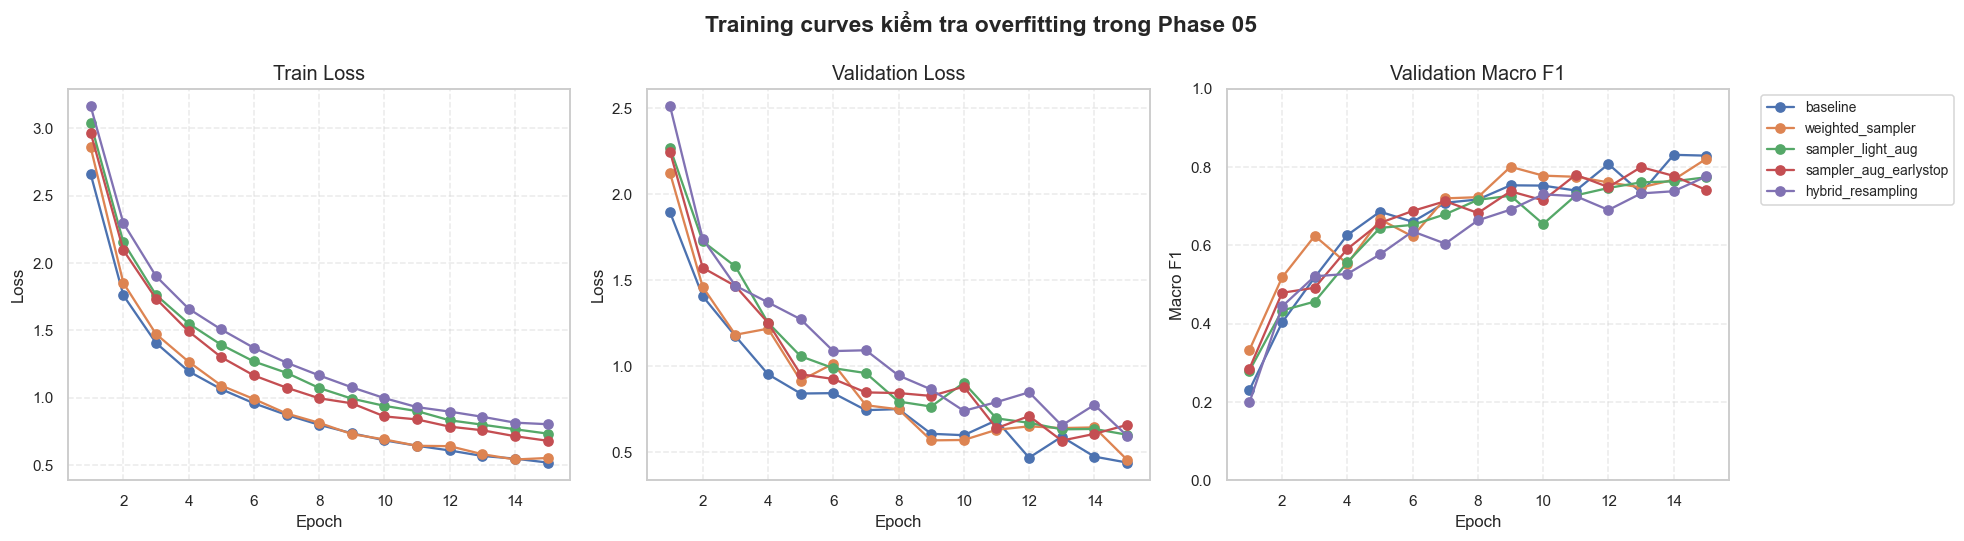

In [7]:
if len(training_histories) == 0:
    print('Không có training history. Nếu FORCE_TRAIN=False và model được load từ checkpoint, curves sẽ không có.')
else:
    plot_learning_curves(
        histories=training_histories,
        save_path=RESULTS_DIR / 'training_curves_overfitting_check.png',
        title='Training curves kiểm tra overfitting trong Phase 05',
    )



# 08_thiet_lap_phase05_analysis
Thiết lập thư mục output riêng cho phần phân tích mất cân bằng lớp ở Phase 05.

Phần này không thay đổi pipeline huấn luyện. Notebook chỉ sử dụng lại kết quả đã có trong `experiments_results` và `training_histories`.


In [8]:
PHASE05_ANALYSIS_DIR = RESULTS_DIR / 'phase_05_analysis'
PHASE05_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

PHASE05_FIGURE_DIR = PHASE05_ANALYSIS_DIR / 'figures'
PHASE05_TABLE_DIR = PHASE05_ANALYSIS_DIR / 'tables'
PHASE05_REPORT_DIR = PHASE05_ANALYSIS_DIR / 'reports'

for directory in [PHASE05_FIGURE_DIR, PHASE05_TABLE_DIR, PHASE05_REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PHASE05_EXPERIMENTS = [
    'baseline',
    'weighted_sampler',
    'sampler_light_aug',
    'sampler_aug_earlystop',
    'hybrid_resampling',
]

available_experiments = [name for name in PHASE05_EXPERIMENTS if name in experiments_results]
missing_experiments = [name for name in PHASE05_EXPERIMENTS if name not in experiments_results]

print('Available Phase 05 experiments:', available_experiments)
if missing_experiments:
    print('Missing experiments. Run the training cell first:', missing_experiments)

class_info_df = class_map_df.sort_values('class_id').reset_index(drop=True).copy()
class_id_to_name = dict(zip(class_info_df['class_id'], class_info_df['class_name']))
class_names_list = [class_id_to_name[class_id] for class_id in sorted(class_id_to_name)]

train_class_counts = train_df['class_id'].value_counts().sort_index()
minority_threshold = train_class_counts.quantile(0.25)
minority_ids = train_class_counts[train_class_counts <= minority_threshold].index.tolist()

print(f'Nguong minority class (phan vi 25%): {minority_threshold:.1f} samples')
print('Detected minority class IDs:', minority_ids)



Available Phase 05 experiments: ['baseline', 'weighted_sampler', 'sampler_light_aug', 'sampler_aug_earlystop', 'hybrid_resampling']
Nguong minority class (phan vi 25%): 157.5 samples
Detected minority class IDs: [0, 2, 6, 9, 14, 17, 22, 23, 31, 36]


# 09_phan_tich_metric_theo_tung_lop
Tạo bảng metric theo từng class cho toàn bộ experiment trong Phase 05.

Bảng này giúp đánh giá model ở mức class, đặc biệt là các class thiểu số. Nếu chỉ nhìn metric trung bình, ta có thể bỏ sót việc model dự đoán rất kém ở một số bệnh hiếm.


In [9]:
def build_per_class_metrics_table(experiments_results, experiment_names):
    """Build per-class Precision/Recall/F1 table for all experiments."""
    records = []

    for experiment_name in experiment_names:
        result = experiments_results[experiment_name]

        for class_id in sorted(class_id_to_name):
            records.append({
                'Experiment': experiment_name,
                'Class_ID': class_id,
                'Class': class_id_to_name[class_id],
                'Train Sample Count': int(train_class_counts.get(class_id, 0)),
                'Test Sample Count': int((test_df['class_id'] == class_id).sum()),
                'Is Minority': class_id in minority_ids,
                'Precision': result['per_class_precision'][class_id],
                'Recall': result['per_class_recall'][class_id],
                'F1-score': result['per_class_f1'][class_id],
            })

    return pd.DataFrame(records)


per_class_metrics_df = build_per_class_metrics_table(
    experiments_results=experiments_results,
    experiment_names=available_experiments,
)

per_class_metrics_path = PHASE05_TABLE_DIR / 'per_class_metrics_all_experiments.csv'
per_class_metrics_df.to_csv(per_class_metrics_path, index=False)

print(f'Saved per-class metrics to: {per_class_metrics_path}')
display(per_class_metrics_df.head(20))


Saved per-class metrics to: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/tables/per_class_metrics_all_experiments.csv


,Experiment,Class_ID,Class,Train Sample Count,Test Sample Count,Is Minority,Precision,Recall,F1-score
0,baseline,0,Apple___Apple_scab,100,18,True,0.714286,0.277778,0.400000
1,baseline,1,Apple___Black_rot,223,18,False,0.818182,0.500000,0.620690
2,baseline,2,Apple___Cedar_apple_rust,99,8,True,0.875000,0.875000,0.875000
3,baseline,3,Apple___healthy,263,49,False,0.838710,0.530612,0.650000
4,baseline,4,Blueberry___healthy,240,45,False,0.833333,0.888889,0.860215
5,baseline,5,Cherry_(including_sour)___Powdery_mildew,168,31,False,0.928571,0.838710,0.881356
6,baseline,6,Cherry_(including_sour)___healthy,136,25,True,1.000000,0.600000,0.750000
7,baseline,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,184,15,False,0.750000,0.600000,0.666667
8,baseline,8,Corn_(maize)___Common_rust_,190,36,False,0.972222,0.972222,0.972222
9,baseline,9,Corn_(maize)___Northern_Leaf_Blight,157,29,True,0.827586,0.827586,0.827586


In [10]:
PRIMARY_BEST_EXPERIMENT = 'sampler_aug_earlystop'
if PRIMARY_BEST_EXPERIMENT not in experiments_results:
    PRIMARY_BEST_EXPERIMENT = max(
        available_experiments,
        key=lambda name: experiments_results[name]['macro_f1'],
    )

baseline_metrics = per_class_metrics_df[per_class_metrics_df['Experiment'] == 'baseline'].copy()
best_metrics = per_class_metrics_df[per_class_metrics_df['Experiment'] == PRIMARY_BEST_EXPERIMENT].copy()

improvement_df = baseline_metrics[[
    'Class_ID', 'Class', 'Train Sample Count', 'Test Sample Count', 'Is Minority', 'Recall', 'F1-score'
]].rename(columns={
    'Recall': 'Baseline Recall',
    'F1-score': 'Baseline F1',
})

best_subset = best_metrics[['Class_ID', 'Recall', 'F1-score']].rename(columns={
    'Recall': 'Best Recall',
    'F1-score': 'Best F1',
})

improvement_df = improvement_df.merge(best_subset, on='Class_ID', how='left')
improvement_df['Recall Improvement'] = improvement_df['Best Recall'] - improvement_df['Baseline Recall']
improvement_df['F1 Improvement'] = improvement_df['Best F1'] - improvement_df['Baseline F1']

improvement_path = PHASE05_TABLE_DIR / 'baseline_vs_best_per_class_improvement.csv'
improvement_df.to_csv(improvement_path, index=False)

print(f'Primary best experiment for analysis: {PRIMARY_BEST_EXPERIMENT}')
print(f'Saved improvement table to: {improvement_path}')
display(improvement_df.sort_values('Recall Improvement', ascending=False).head(15))


Primary best experiment for analysis: sampler_aug_earlystop
Saved improvement table to: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/tables/baseline_vs_best_per_class_improvement.csv


,Class_ID,Class,Train Sample Count,Test Sample Count,Is Minority,Baseline Recall,Baseline F1,Best Recall,Best F1,Recall Improvement,F1 Improvement
1,1,Apple___Black_rot,223,18,False,0.500000,0.620690,0.888889,0.842105,0.388889,0.221416
6,6,Cherry_(including_sour)___healthy,136,25,True,0.600000,0.750000,0.960000,0.761905,0.360000,0.011905
18,18,"Pepper,_bell___Bacterial_spot",159,29,False,0.517241,0.535714,0.862069,0.609756,0.344828,0.074042
14,14,Grape___healthy,152,12,True,0.583333,0.700000,0.916667,0.785714,0.333333,0.085714
0,0,Apple___Apple_scab,100,18,True,0.277778,0.400000,0.555556,0.588235,0.277778,0.188235
36,36,Tomato___Tomato_mosaic_virus,134,11,True,0.727273,0.695652,1.000000,0.758621,0.272727,0.062969
22,22,Potato___healthy,54,8,True,0.625000,0.625000,0.875000,0.482759,0.250000,-0.142241
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,184,15,False,0.600000,0.666667,0.800000,0.827586,0.200000,0.160920
3,3,Apple___healthy,263,49,False,0.530612,0.650000,0.693878,0.731183,0.163265,0.081183
2,2,Apple___Cedar_apple_rust,99,8,True,0.875000,0.875000,1.000000,0.888889,0.125000,0.013889


In [11]:
LOW_RECALL_THRESHOLD = 0.50

top_improved_minority_df = (
    improvement_df[improvement_df['Is Minority']]
    .sort_values('Recall Improvement', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

hardest_classes_df = (
    best_metrics
    .sort_values(['Recall', 'F1-score'], ascending=[True, True])
    .head(10)
    .reset_index(drop=True)
)

low_recall_classes_df = (
    best_metrics[best_metrics['Recall'] < LOW_RECALL_THRESHOLD]
    .sort_values('Recall', ascending=True)
    .reset_index(drop=True)
)

top_improved_minority_df.to_csv(PHASE05_TABLE_DIR / 'top_improved_minority_classes.csv', index=False)
hardest_classes_df.to_csv(PHASE05_TABLE_DIR / 'hardest_classes.csv', index=False)
low_recall_classes_df.to_csv(PHASE05_TABLE_DIR / 'low_recall_classes.csv', index=False)

print('Cac class thieu so cai thien nhieu nhat:')
display(top_improved_minority_df)

print('Cac class kho hoc nhat duoi model tot nhat:')
display(hardest_classes_df[['Class_ID', 'Class', 'Train Sample Count', 'Recall', 'F1-score']])

print(f'Cac class co Recall < {LOW_RECALL_THRESHOLD}:')
display(low_recall_classes_df[['Class_ID', 'Class', 'Train Sample Count', 'Recall', 'F1-score']])



Cac class thieu so cai thien nhieu nhat:


,Class_ID,Class,Train Sample Count,Test Sample Count,Is Minority,Baseline Recall,Baseline F1,Best Recall,Best F1,Recall Improvement,F1 Improvement
0,6,Cherry_(including_sour)___healthy,136,25,True,0.600000,0.750000,0.960000,0.761905,0.360000,0.011905
1,14,Grape___healthy,152,12,True,0.583333,0.700000,0.916667,0.785714,0.333333,0.085714
2,0,Apple___Apple_scab,100,18,True,0.277778,0.400000,0.555556,0.588235,0.277778,0.188235
3,36,Tomato___Tomato_mosaic_virus,134,11,True,0.727273,0.695652,1.000000,0.758621,0.272727,0.062969
4,22,Potato___healthy,54,8,True,0.625000,0.625000,0.875000,0.482759,0.250000,-0.142241
5,2,Apple___Cedar_apple_rust,99,8,True,0.875000,0.875000,1.000000,0.888889,0.125000,0.013889
6,31,Tomato___Leaf_Mold,152,28,True,0.642857,0.720000,0.750000,0.700000,0.107143,-0.020000
7,9,Corn_(maize)___Northern_Leaf_Blight,157,29,True,0.827586,0.827586,0.931034,0.900000,0.103448,0.072414
8,17,Peach___healthy,129,10,True,1.000000,1.000000,1.000000,0.952381,0.000000,-0.047619
9,23,Raspberry___healthy,133,11,True,1.000000,0.880000,1.000000,0.956522,0.000000,0.076522


Cac class kho hoc nhat duoi model tot nhat:


,Class_ID,Class,Train Sample Count,Recall,F1-score
0,19,"Pepper,_bell___healthy",236,0.522727,0.676471
1,16,Peach___Bacterial_spot,367,0.550725,0.612903
2,0,Apple___Apple_scab,100,0.555556,0.588235
3,30,Tomato___Late_blight,305,0.561404,0.646465
4,32,Tomato___Septoria_leaf_spot,283,0.584906,0.596154
5,29,Tomato___Early_blight,160,0.633333,0.745098
6,3,Apple___healthy,263,0.693878,0.731183
7,21,Potato___Late_blight,160,0.733333,0.709677
8,31,Tomato___Leaf_Mold,152,0.750000,0.700000
9,28,Tomato___Bacterial_spot,340,0.793651,0.806452


Cac class co Recall < 0.5:


,Class_ID,Class,Train Sample Count,Recall,F1-score


# 10_phan_tich_confusion_matrix
Vẽ confusion matrix được chuẩn hóa theo true label cho baseline và model chính `sampler_aug_earlystop`.

Chuẩn hóa theo true label giúp đọc Recall theo từng class: mỗi hàng biểu diễn một class thật, và các ô trên hàng đó cho biết model đã phân loại class này sang những class nào.


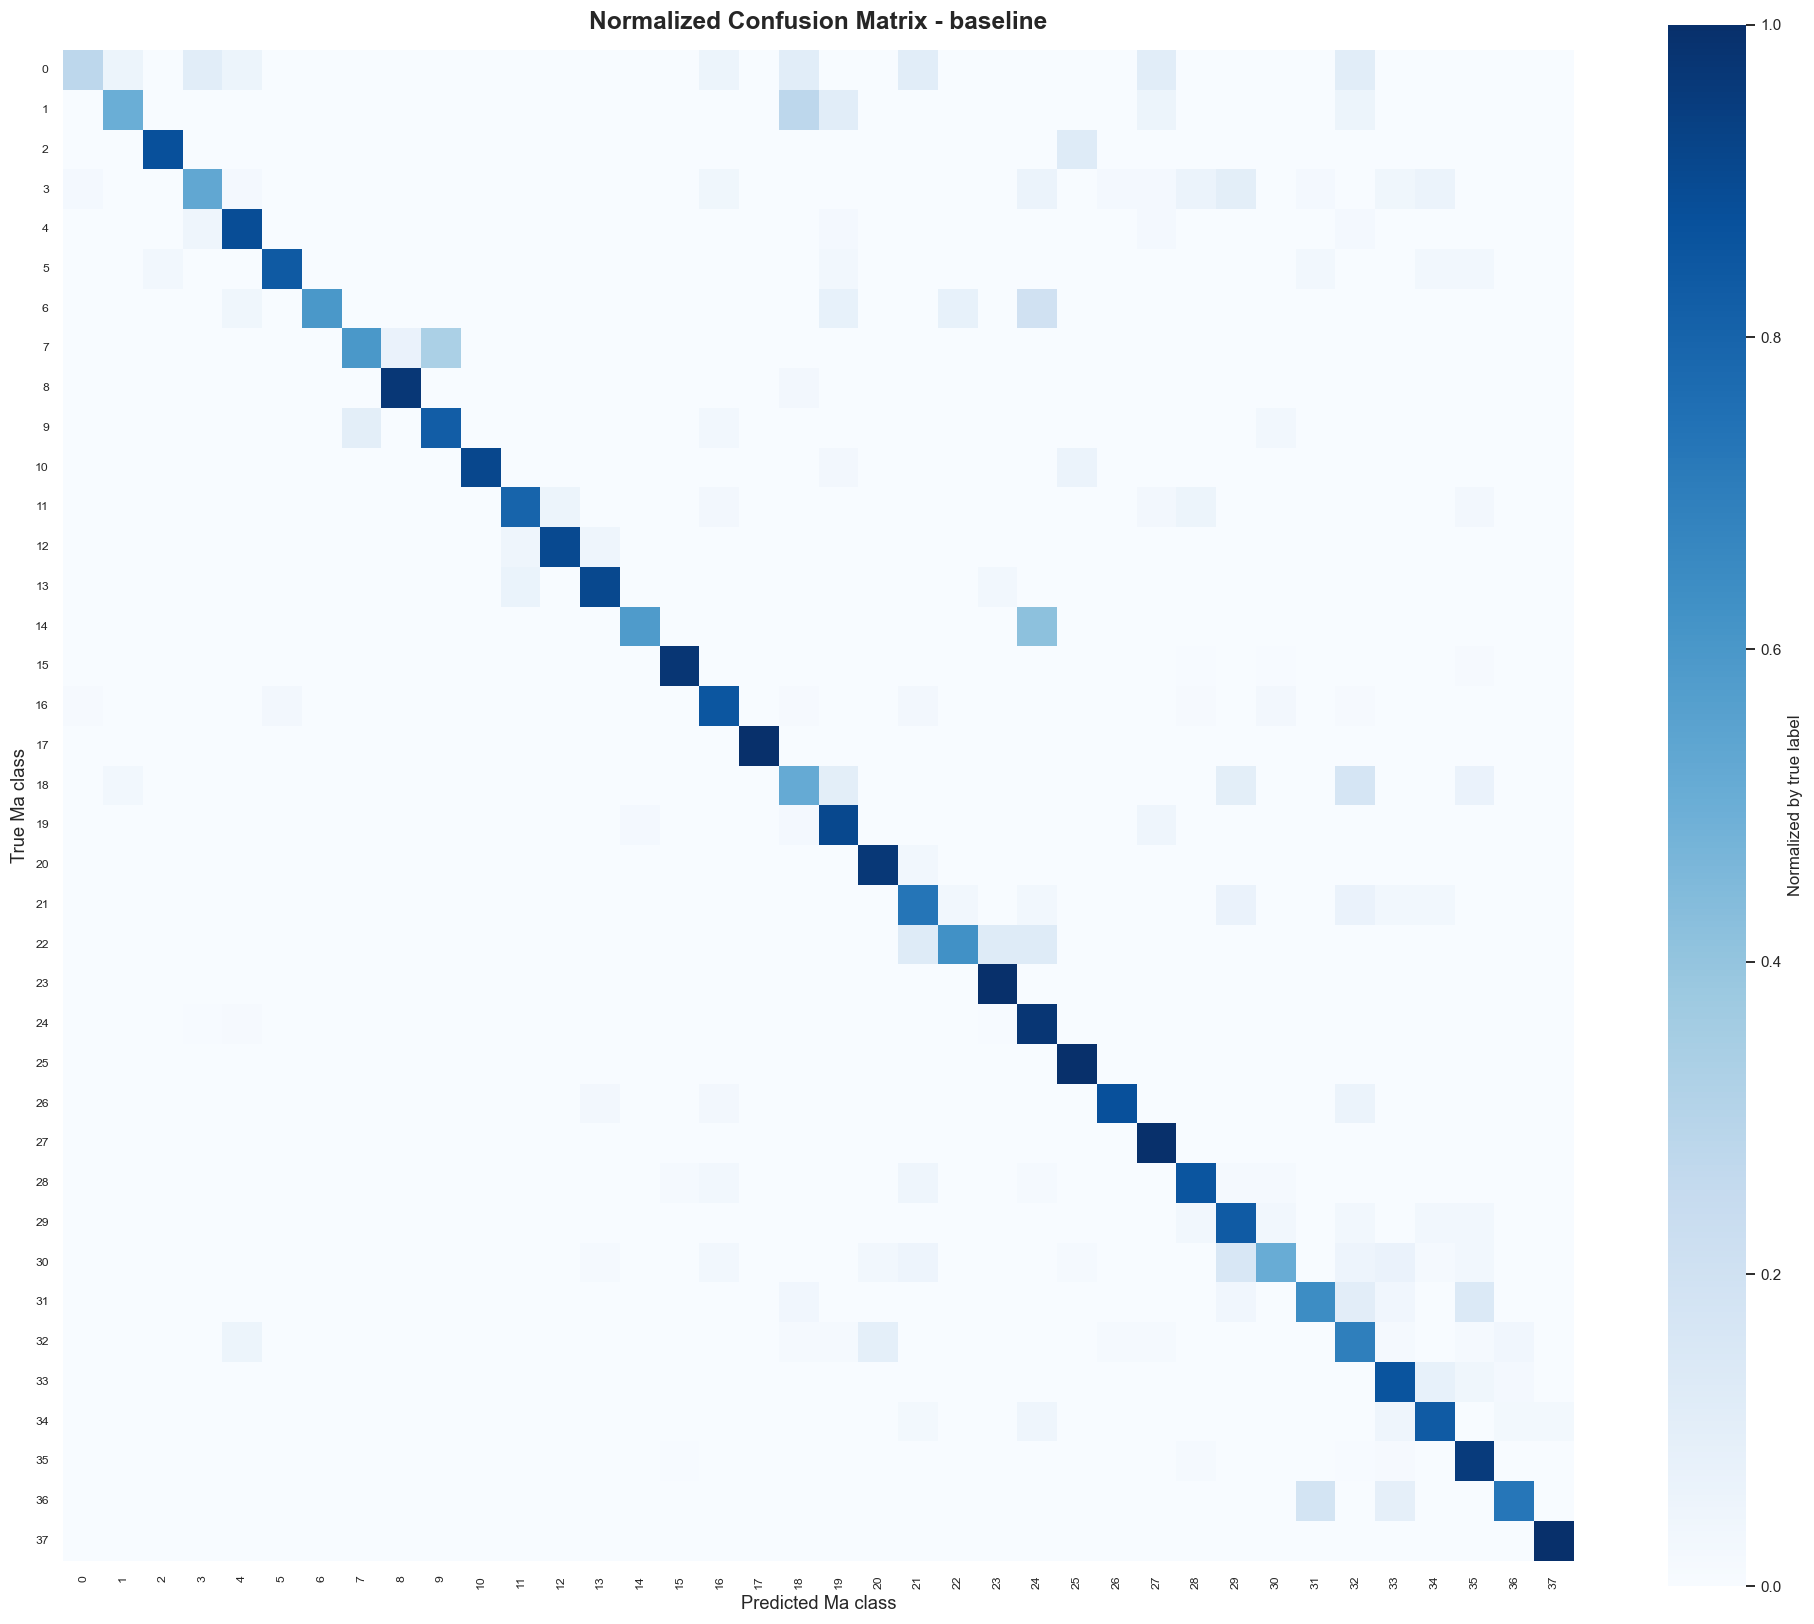

Da luu confusion matrix: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/figures/confusion_matrix_baseline_normalized.png


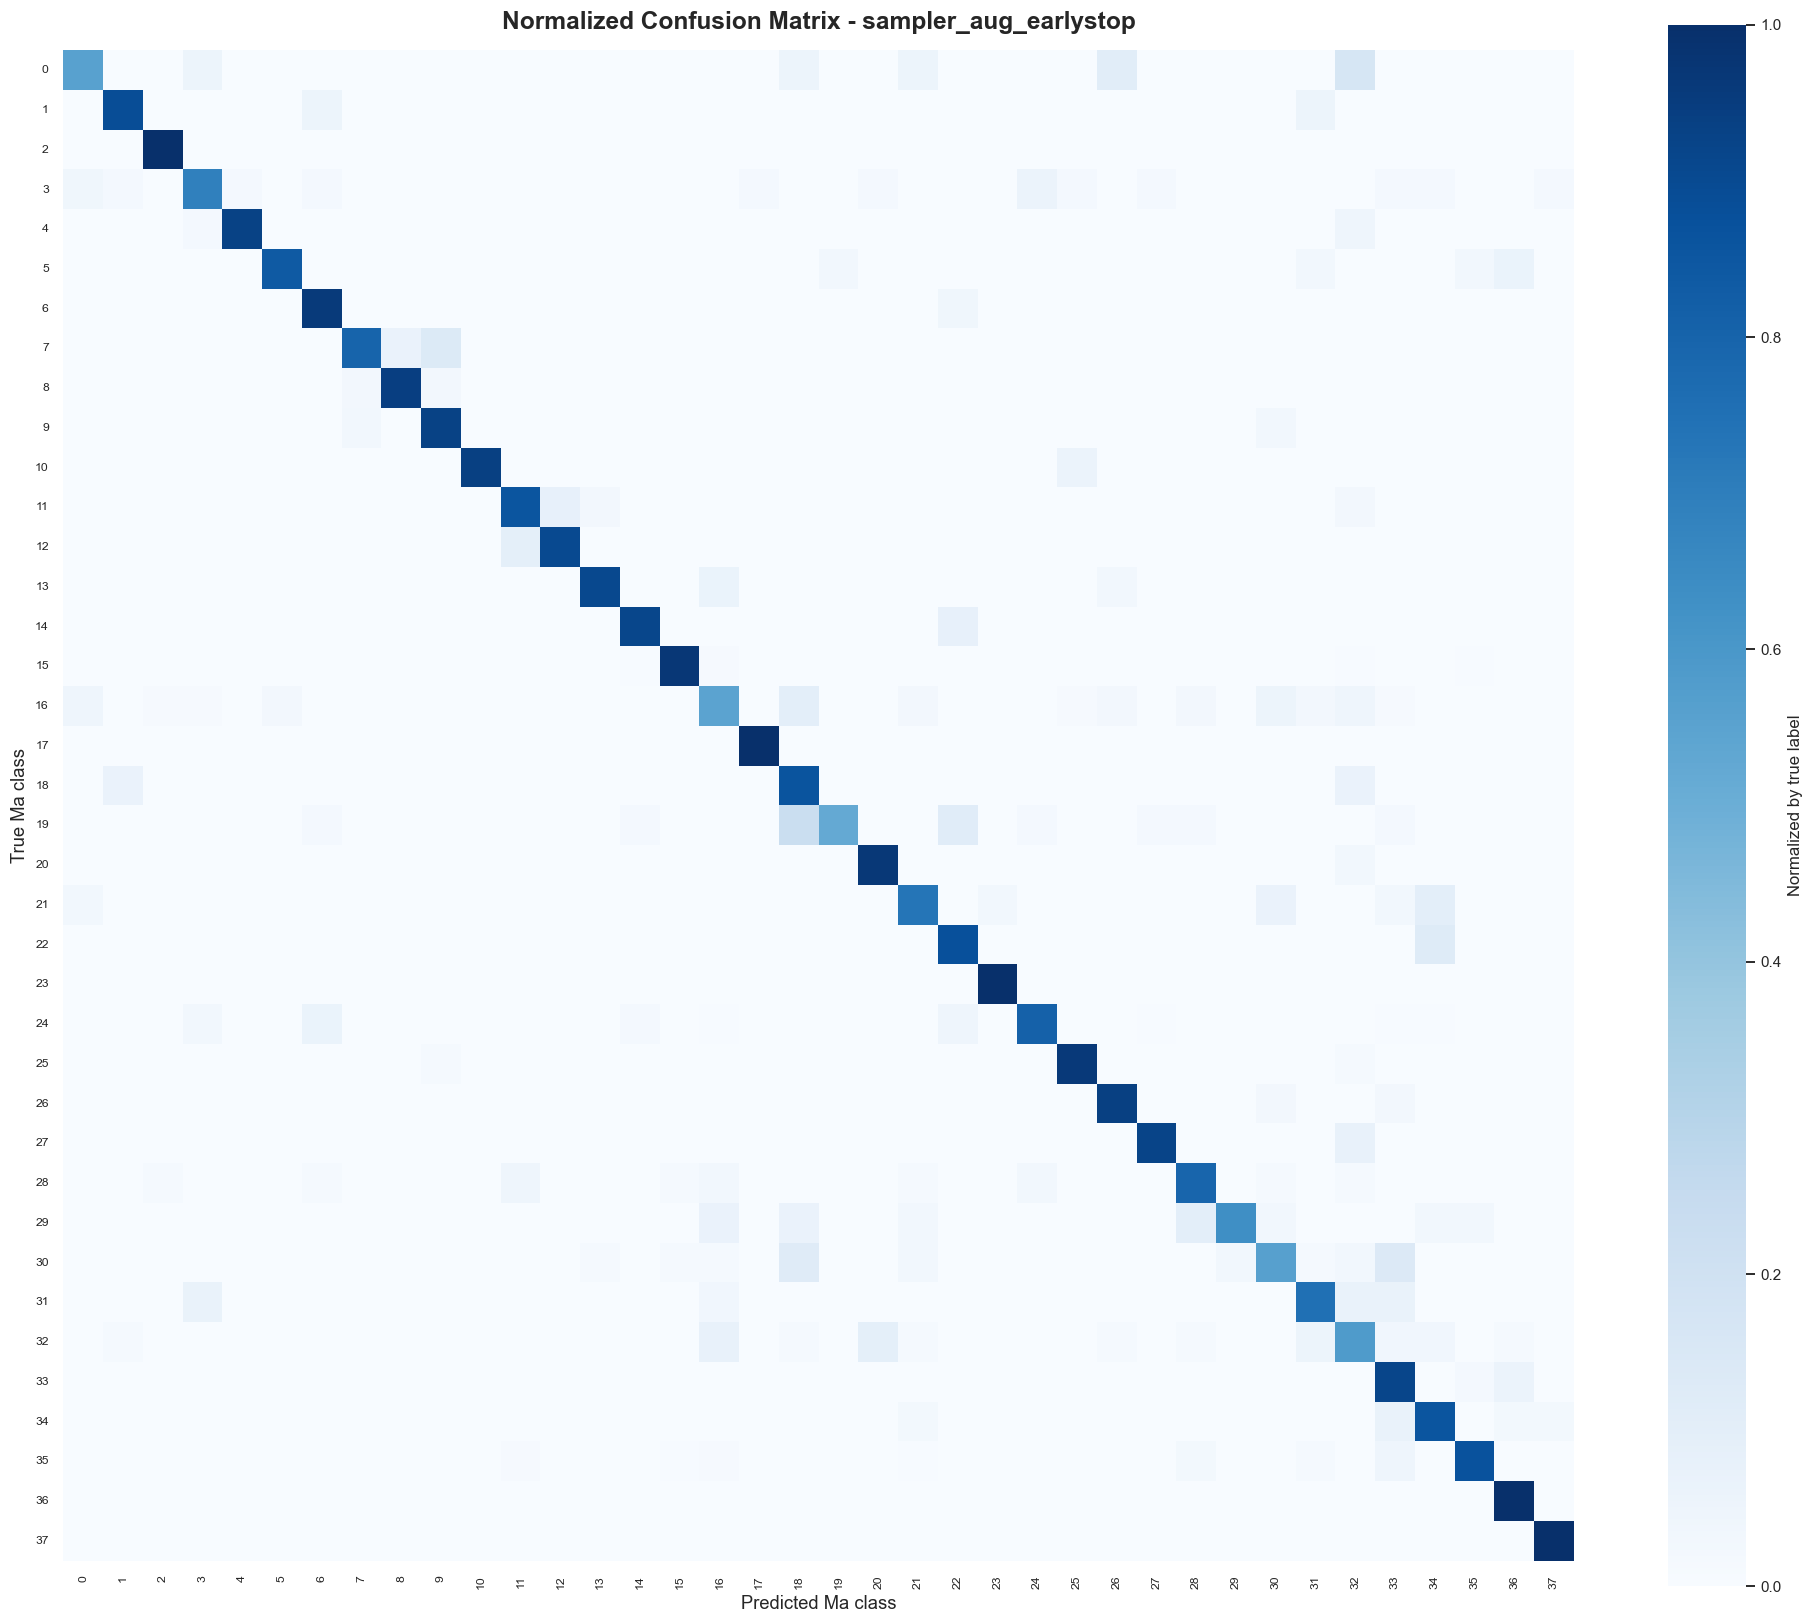

Da luu confusion matrix: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/figures/confusion_matrix_sampler_aug_earlystop_normalized.png


In [12]:
def plot_normalized_confusion_matrix(experiment_name, result, filename):
    """Plot normalized confusion matrix by true labels."""
    cm = confusion_matrix(result['labels'], result['preds'], labels=list(range(38)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_normalized = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(18, 15))
    sns.heatmap(
        cm_normalized,
        cmap='Blues',
        vmin=0,
        vmax=1,
        square=True,
        cbar_kws={'label': 'Normalized by true label'},
        ax=ax,
    )

    ax.set_title(f'Normalized Confusion Matrix - {experiment_name}', fontsize=16, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Ma class', fontsize=12)
    ax.set_ylabel('True Ma class', fontsize=12)
    ax.set_xticks(np.arange(38) + 0.5)
    ax.set_yticks(np.arange(38) + 0.5)
    ax.set_xticklabels(range(38), rotation=90, fontsize=8)
    ax.set_yticklabels(range(38), rotation=0, fontsize=8)

    plt.tight_layout()
    save_path = PHASE05_FIGURE_DIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Da luu confusion matrix: {save_path}')
    return cm, cm_normalized


cm_baseline, cm_baseline_norm = plot_normalized_confusion_matrix(
    'baseline',
    experiments_results['baseline'],
    'confusion_matrix_baseline_normalized.png',
)

cm_best, cm_best_norm = plot_normalized_confusion_matrix(
    PRIMARY_BEST_EXPERIMENT,
    experiments_results[PRIMARY_BEST_EXPERIMENT],
    f'confusion_matrix_{PRIMARY_BEST_EXPERIMENT}_normalized.png',
)



In [13]:
def get_top_confusing_pairs(cm, top_n=20):
    """Return most frequent off-diagonal confusion pairs."""
    records = []

    for true_class in range(cm.shape[0]):
        row_total = cm[true_class].sum()
        for pred_class in range(cm.shape[1]):
            if true_class == pred_class:
                continue
            confused_count = int(cm[true_class, pred_class])
            if confused_count == 0:
                continue

            records.append({
                'True Class ID': true_class,
                'True Class': class_id_to_name[true_class],
                'Predicted Class ID': pred_class,
                'Predicted Class': class_id_to_name[pred_class],
                'Confused Samples': confused_count,
                'Confusion Rate Within True Class': confused_count / row_total if row_total > 0 else 0,
            })

    return (
        pd.DataFrame(records)
        .sort_values(['Confused Samples', 'Confusion Rate Within True Class'], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


top_confusing_pairs_df = get_top_confusing_pairs(cm_best, top_n=20)
top_confusing_pairs_path = PHASE05_TABLE_DIR / 'top_confusing_class_pairs.csv'
top_confusing_pairs_df.to_csv(top_confusing_pairs_path, index=False)

print(f'Saved confusing class pairs to: {top_confusing_pairs_path}')
display(top_confusing_pairs_df)


Saved confusing class pairs to: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/tables/top_confusing_class_pairs.csv


,True Class ID,True Class,Predicted Class ID,Predicted Class,Confused Samples,Confusion Rate Within True Class
0,19,"Pepper,_bell___healthy",18,"Pepper,_bell___Bacterial_spot",10,0.227273
1,24,Soybean___healthy,6,Cherry_(including_sour)___healthy,10,0.065789
2,30,Tomato___Late_blight,33,Tomato___Spider_mites Two-spotted_spider_mite,8,0.140351
3,35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,33,Tomato___Spider_mites Two-spotted_spider_mite,8,0.050000
4,30,Tomato___Late_blight,18,"Pepper,_bell___Bacterial_spot",7,0.122807
5,16,Peach___Bacterial_spot,18,"Pepper,_bell___Bacterial_spot",7,0.101449
6,24,Soybean___healthy,22,Potato___healthy,7,0.046053
7,19,"Pepper,_bell___healthy",22,Potato___healthy,5,0.113636
8,32,Tomato___Septoria_leaf_spot,20,Potato___Early_blight,5,0.094340
9,24,Soybean___healthy,3,Apple___healthy,5,0.032895


# 11_phan_tich_learning_curve
So sánh learning curve của baseline, weighted sampler và sampler kết hợp augmentation + early stopping.

Mục tiêu là quan sát dấu hiệu overfitting: train loss giảm nhưng validation Macro F1 không tăng tương ứng. Đây là hiện tượng dễ gặp khi minority samples bị lặp lại nhiều lần.


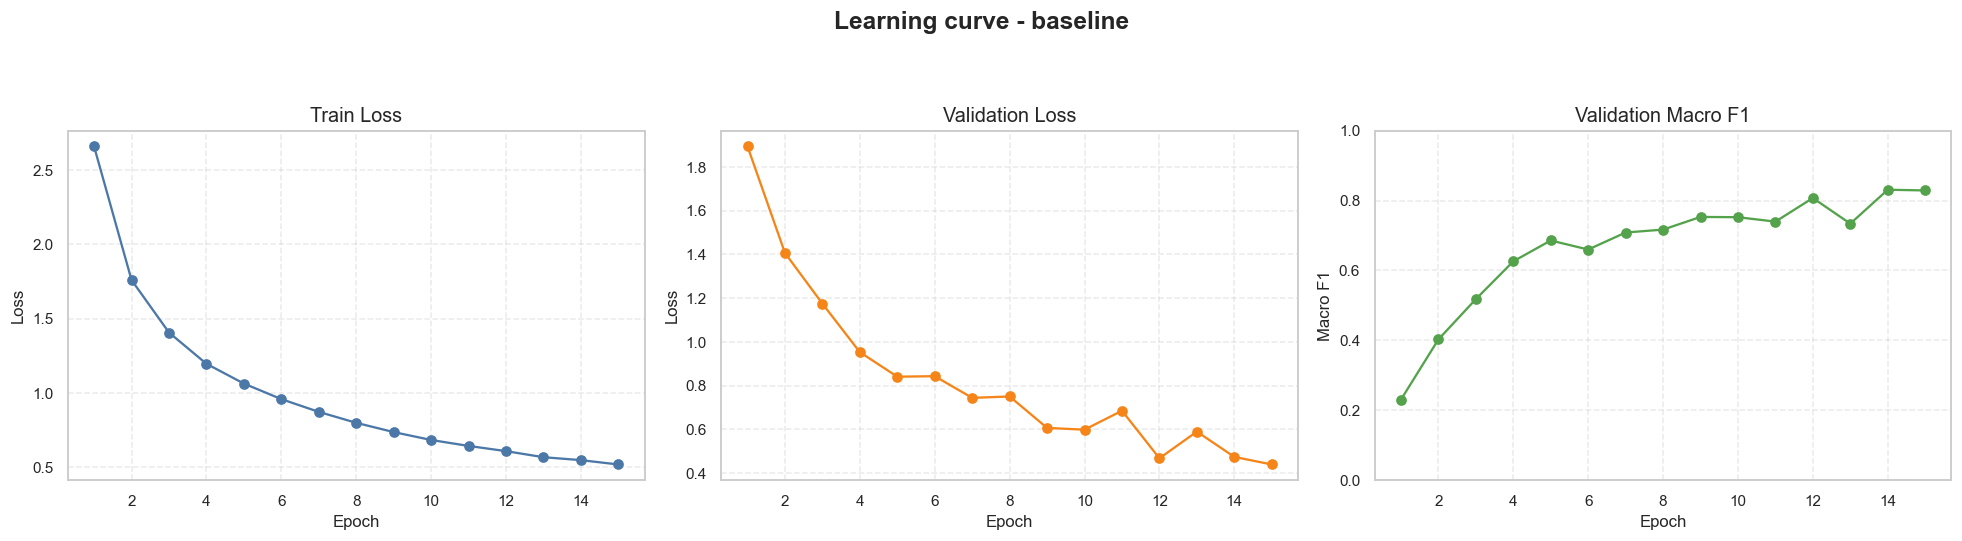

Đã lưu learning curve: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/figures/learning_curves_baseline.png


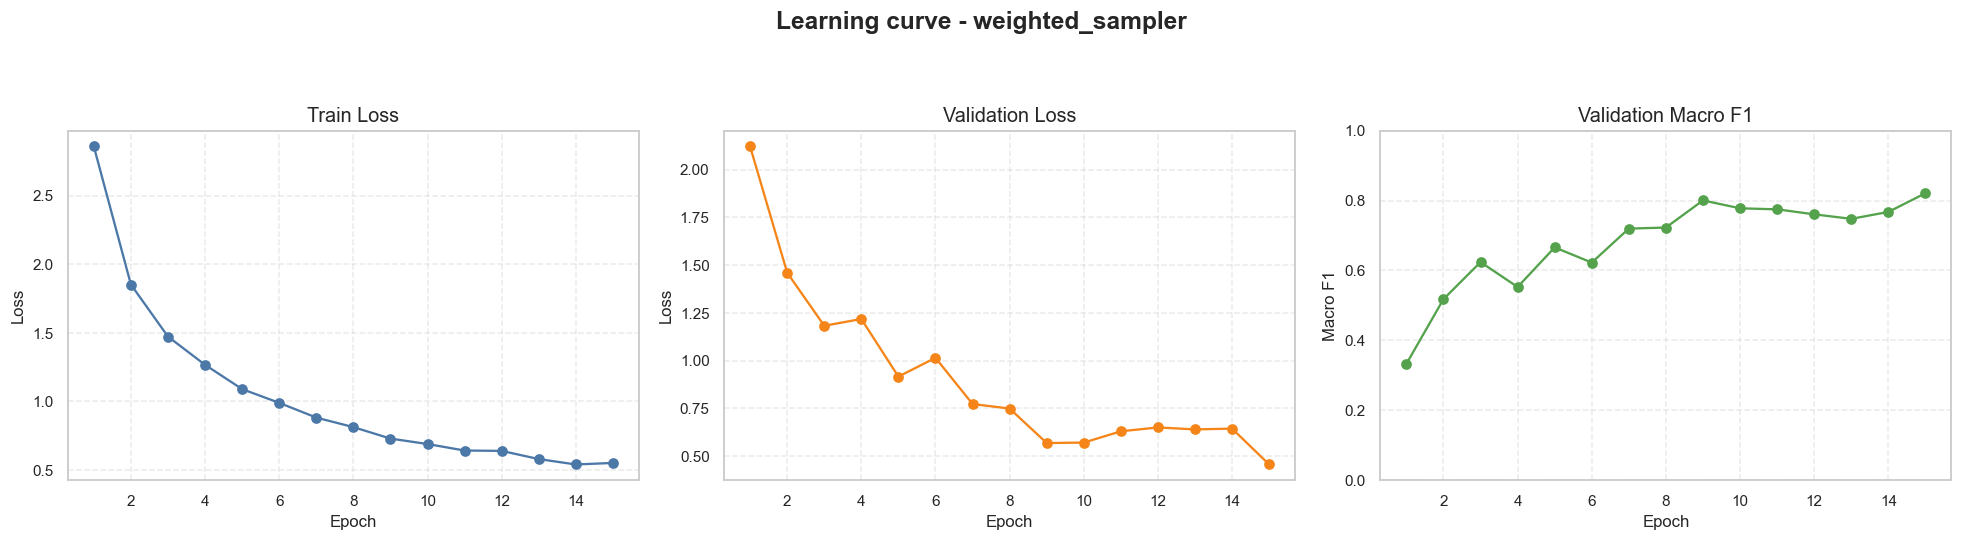

Đã lưu learning curve: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/figures/learning_curves_weighted_sampler.png


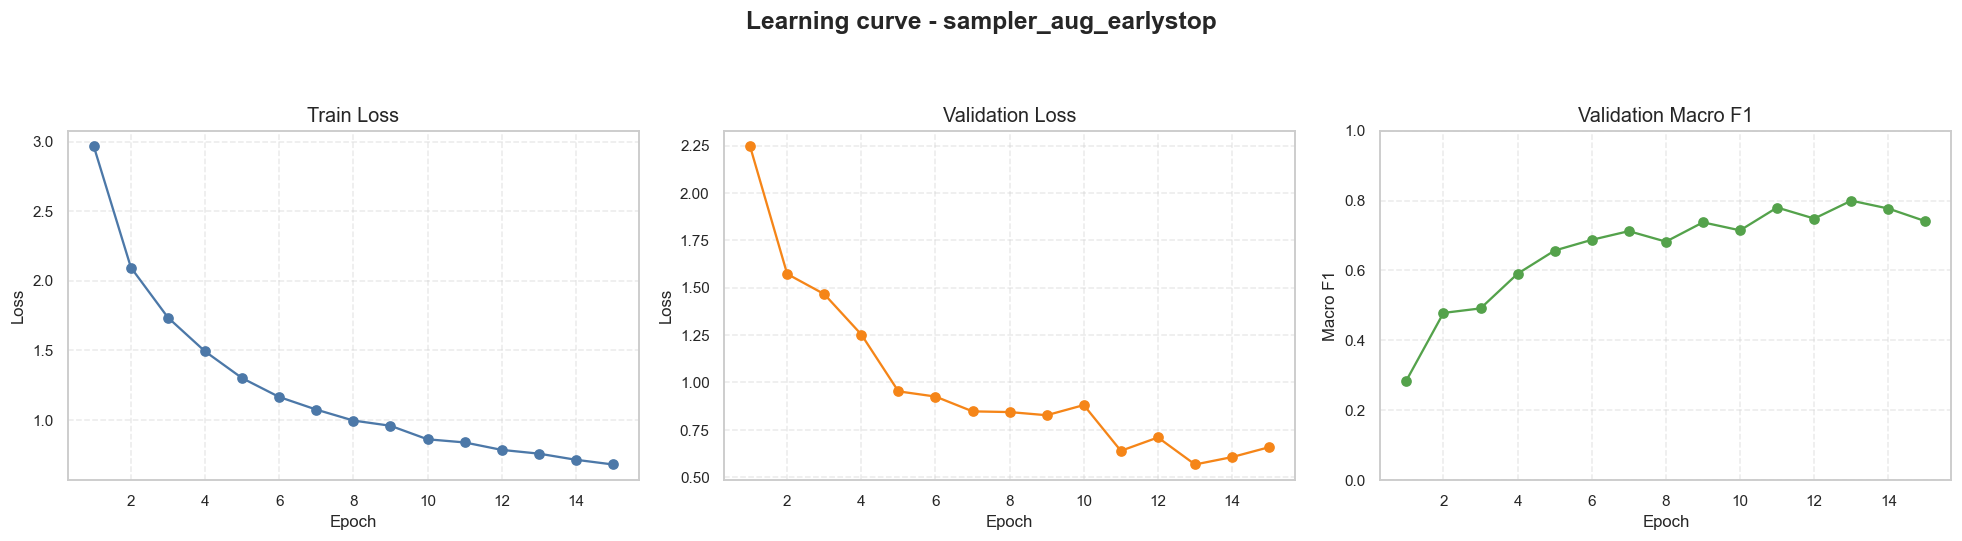

Đã lưu learning curve: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/figures/learning_curves_sampler_aug_earlystop.png


In [14]:
def plot_selected_learning_curves(training_histories, selected_experiments):
    """Ve rieng learning curve cho tung experiment de dua vao bao cao."""
    for experiment_name in selected_experiments:
        if experiment_name not in training_histories:
            print(f'Bỏ qua {experiment_name}: chưa có lịch sử huấn luyện.')
            continue

        history = training_histories[experiment_name]
        epochs_range = range(1, len(history['train_loss']) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(epochs_range, history['train_loss'], marker='o', color='#4C78A8')
        axes[0].set_title('Train Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True, linestyle='--', alpha=0.4)

        axes[1].plot(epochs_range, history['val_loss'], marker='o', color='#F58518')
        axes[1].set_title('Validation Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True, linestyle='--', alpha=0.4)

        axes[2].plot(epochs_range, history['val_f1'], marker='o', color='#54A24B')
        axes[2].set_title('Validation Macro F1')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Macro F1')
        axes[2].set_ylim(0, 1)
        axes[2].grid(True, linestyle='--', alpha=0.4)

        fig.suptitle(f'Learning curve - {experiment_name}', fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.92])

        save_path = PHASE05_FIGURE_DIR / f'learning_curves_{experiment_name}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Đã lưu learning curve: {save_path}')


plot_selected_learning_curves(
    training_histories,
    selected_experiments=['baseline', 'weighted_sampler', 'sampler_aug_earlystop'],
)




# 12_truc_quan_hoa_lop_thieu_so
Tạo các biểu đồ phục vụ báo cáo: phân phối class, so sánh Minority Recall và so sánh Worst-class Recall giữa các experiment.

Các biểu đồ này giúp thấy rõ phương pháp nào cải thiện khả năng nhận diện class thiểu số thay vì chỉ tối ưu Accuracy tổng thể.


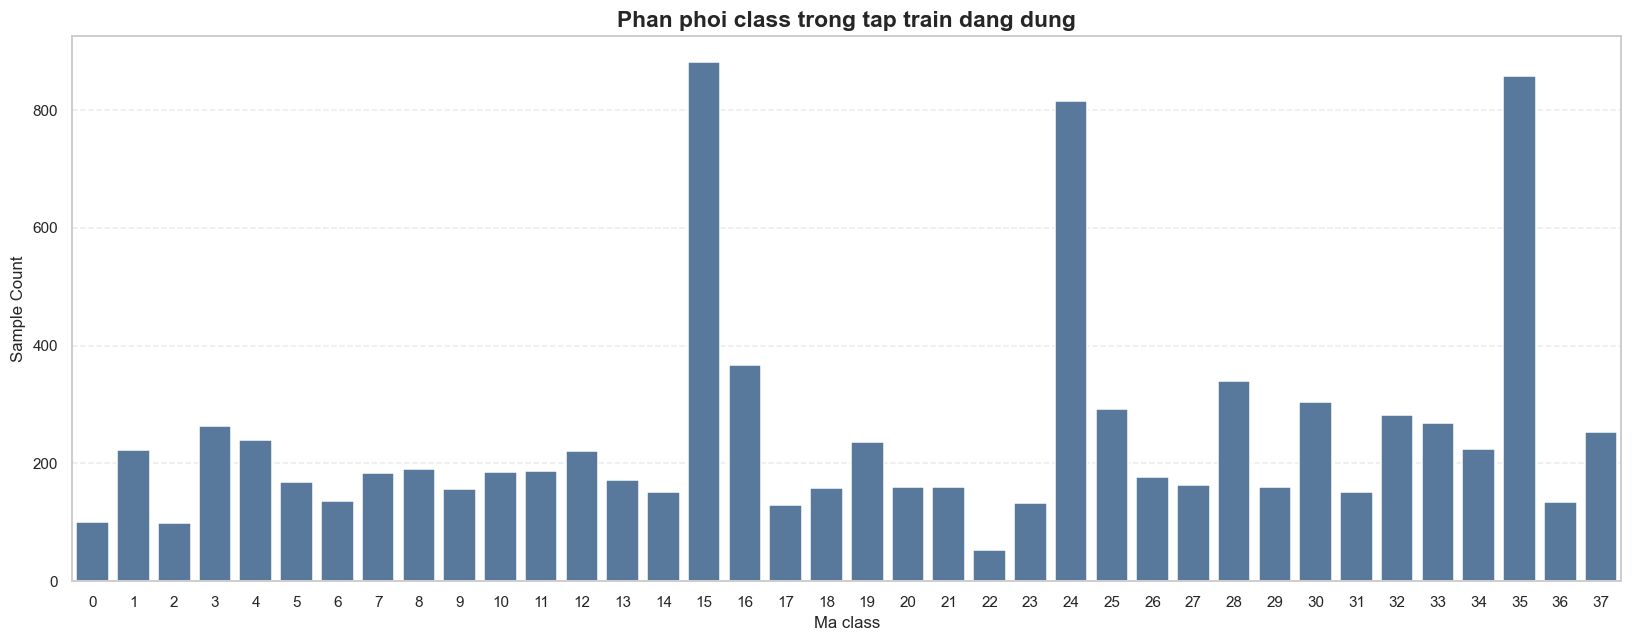

In [15]:
def annotate_bars(ax, fmt='{:.2f}', y_offset=0.01):
    """Annotate bar values for readability."""
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + y_offset,
            fmt.format(height),
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=0,
        )


fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=dist_df, x='class_id', y='sample_count', color='#4C78A8', ax=ax)
ax.set_title('Phan phoi class trong tap train dang dung', fontsize=15, fontweight='bold')
ax.set_xlabel('Ma class')
ax.set_ylabel('Sample Count')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(PHASE05_FIGURE_DIR / 'class_distribution_active_train.png', dpi=300, bbox_inches='tight')
plt.show()




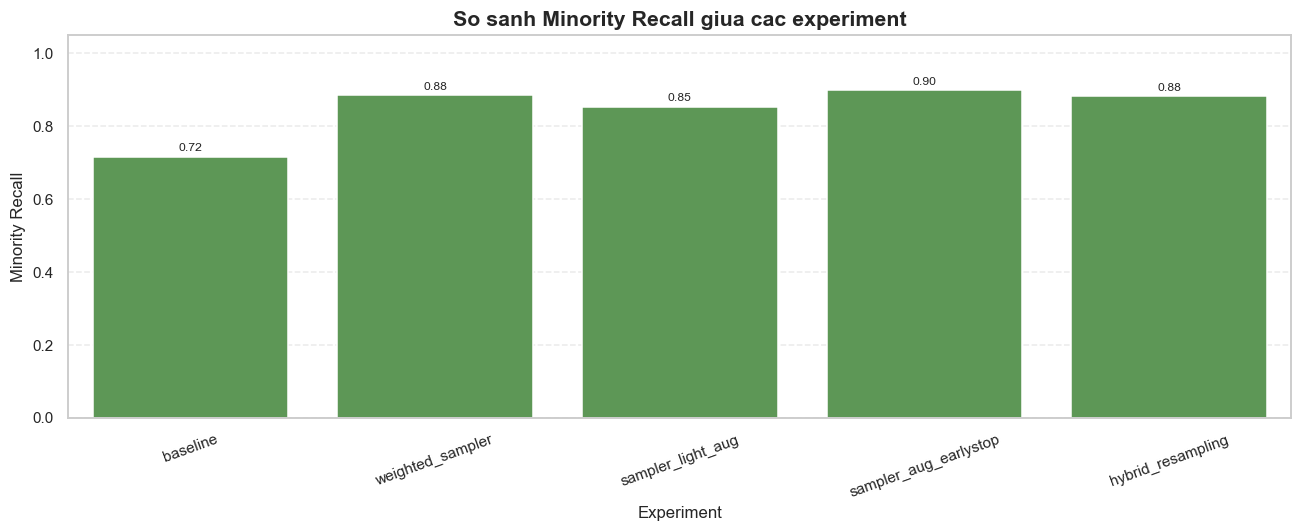

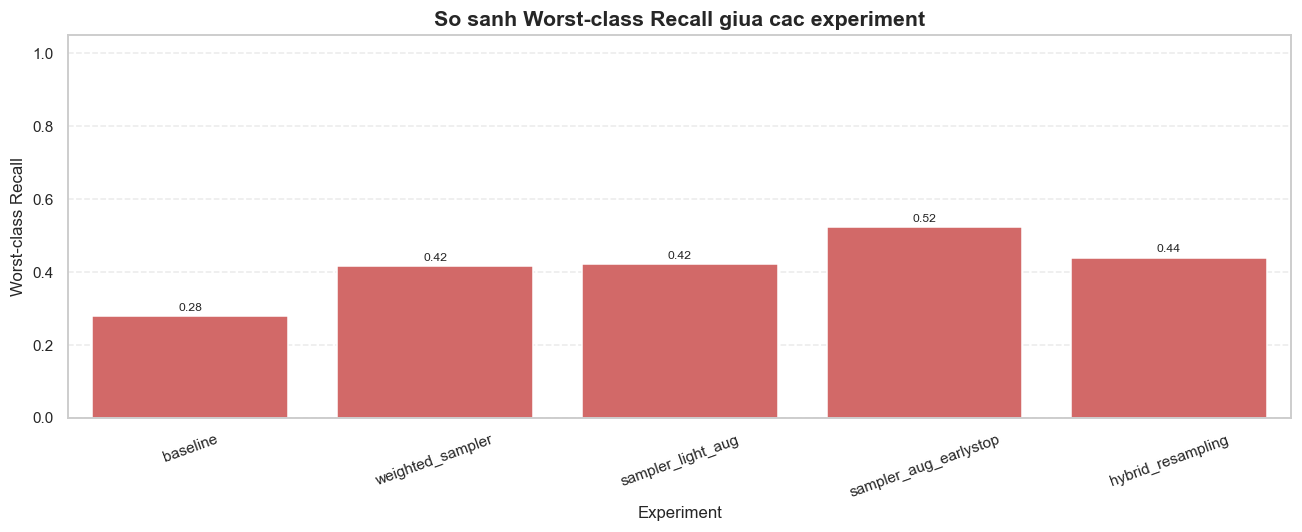

In [16]:
minority_recall_records = []
for experiment_name in available_experiments:
    result = experiments_results[experiment_name]
    minority_recall_records.append({
        'Experiment': experiment_name,
        'Minority Recall': np.mean([result['per_class_recall'][class_id] for class_id in minority_ids]),
        'Worst-class Recall': np.min(result['per_class_recall']),
    })

minority_visual_df = pd.DataFrame(minority_recall_records)
minority_visual_df.to_csv(PHASE05_TABLE_DIR / 'minority_and_worst_recall_by_experiment.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=minority_visual_df, x='Experiment', y='Minority Recall', color='#54A24B', ax=ax)
ax.set_title('So sanh Minority Recall giua cac experiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Experiment')
ax.set_ylabel('Minority Recall')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
annotate_bars(ax)
plt.tight_layout()
plt.savefig(PHASE05_FIGURE_DIR / 'minority_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=minority_visual_df, x='Experiment', y='Worst-class Recall', color='#E45756', ax=ax)
ax.set_title('So sanh Worst-class Recall giua cac experiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Experiment')
ax.set_ylabel('Worst-class Recall')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
annotate_bars(ax)
plt.tight_layout()
plt.savefig(PHASE05_FIGURE_DIR / 'worst_class_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



# 13_phan_tich_loi
Phân tích lỗi chuyên sâu: xác định class khó học nhất, class thường bị nhầm nhiều nhất và nguyên nhân tiềm năng.

Phần này giúp chuyển kết quả số thành insight có ý nghĩa, ví dụ class bị nhầm do triệu chứng bệnh giống nhau, texture chồng lấn, số mẫu ít hoặc ảnh có độ phân giải hạn chế.


In [17]:
def get_plant_name(class_name):
    """Tách tên cây trồng từ nhãn PlantVillage."""
    return class_name.split('___')[0] if '___' in class_name else class_name


def infer_possible_reason(true_class, predicted_classes, train_count, recall_value):
    """Suy luận nguyên nhân lỗi dựa trên tên class, số mẫu train và Recall."""
    reasons = []
    true_plant = get_plant_name(true_class)
    predicted_plants = [get_plant_name(name) for name in predicted_classes]

    if any(plant == true_plant for plant in predicted_plants):
        reasons.append('triệu chứng bệnh giống nhau trên cùng cây trồng')
    else:
        reasons.append('texture hoặc màu sắc chồng lấn giữa các cây trồng')

    if train_count <= minority_threshold:
        reasons.append('số mẫu train thấp')

    if recall_value < LOW_RECALL_THRESHOLD:
        reasons.append('ranh giới thị giác giữa các class chưa rõ')

    if IMAGE_SIZE <= 128:
        reasons.append('giới hạn do ảnh resize ở độ phân giải thấp')

    return '; '.join(reasons)


error_records = []
for class_id in sorted(class_id_to_name):
    class_confusions = top_confusing_pairs_df[top_confusing_pairs_df['True Class ID'] == class_id]
    common_confused_with = class_confusions['Predicted Class'].head(3).tolist()

    if len(common_confused_with) == 0:
        common_confused_with = ['Không nằm trong các cặp nhầm lẫn lớn nhất']

    best_recall = float(best_metrics[best_metrics['Class_ID'] == class_id]['Recall'].iloc[0])
    train_count = int(train_class_counts.get(class_id, 0))

    error_records.append({
        'Class_ID': class_id,
        'Class': class_id_to_name[class_id],
        'Best Model Recall': best_recall,
        'Train Sample Count': train_count,
        'Common Confused With': ', '.join(common_confused_with),
        'Possible Reason': infer_possible_reason(
            true_class=class_id_to_name[class_id],
            predicted_classes=common_confused_with,
            train_count=train_count,
            recall_value=best_recall,
        ),
    })

error_analysis_df = (
    pd.DataFrame(error_records)
    .sort_values(['Best Model Recall', 'Train Sample Count'], ascending=[True, True])
    .reset_index(drop=True)
)

error_analysis_path = PHASE05_TABLE_DIR / 'error_analysis_summary.csv'
error_analysis_df.to_csv(error_analysis_path, index=False)

print(f'Đã lưu bảng phân tích lỗi tại: {error_analysis_path}')
display(error_analysis_df.head(15))



Đã lưu bảng phân tích lỗi tại: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/tables/error_analysis_summary.csv


,Class_ID,Class,Best Model Recall,Train Sample Count,Common Confused With,Possible Reason
0,19,"Pepper,_bell___healthy",0.522727,236,"Pepper,_bell___Bacterial_spot, Potato___healthy",triệu chứng bệnh giống nhau trên cùng cây trồn...
1,16,Peach___Bacterial_spot,0.550725,367,"Pepper,_bell___Bacterial_spot, Tomato___Late_b...",texture hoặc màu sắc chồng lấn giữa các cây tr...
2,0,Apple___Apple_scab,0.555556,100,Tomato___Septoria_leaf_spot,texture hoặc màu sắc chồng lấn giữa các cây tr...
3,30,Tomato___Late_blight,0.561404,305,"Tomato___Spider_mites Two-spotted_spider_mite,...",triệu chứng bệnh giống nhau trên cùng cây trồn...
4,32,Tomato___Septoria_leaf_spot,0.584906,283,"Potato___Early_blight, Peach___Bacterial_spot",texture hoặc màu sắc chồng lấn giữa các cây tr...
5,29,Tomato___Early_blight,0.633333,160,Tomato___Bacterial_spot,triệu chứng bệnh giống nhau trên cùng cây trồn...
6,3,Apple___healthy,0.693878,263,Soybean___healthy,texture hoặc màu sắc chồng lấn giữa các cây tr...
7,21,Potato___Late_blight,0.733333,160,Tomato___Target_Spot,texture hoặc màu sắc chồng lấn giữa các cây tr...
8,31,Tomato___Leaf_Mold,0.750000,152,Không nằm trong các cặp nhầm lẫn lớn nhất,texture hoặc màu sắc chồng lấn giữa các cây tr...
9,28,Tomato___Bacterial_spot,0.793651,340,Không nằm trong các cặp nhầm lẫn lớn nhất,texture hoặc màu sắc chồng lấn giữa các cây tr...


# 14_tong_hop_ablation_study
Tổng hợp ablation study để đánh giá tác động tăng dần của WeightedSampler, Light Augmentation và EarlyStopping.

Ablation study giúp trả lời câu hỏi: kỹ thuật nào thật sự đóng góp vào cải thiện Macro F1, Minority Recall và Worst-class Recall.


In [18]:
def build_ablation_summary(experiments_results, experiment_names):
    """Build compact ablation summary table."""
    records = []

    for experiment_name in experiment_names:
        result = experiments_results[experiment_name]
        records.append({
            'Experiment': experiment_name,
            'Accuracy': result['accuracy'],
            'Macro F1': result['macro_f1'],
            'Minority Recall': np.mean([result['per_class_recall'][class_id] for class_id in minority_ids]),
            'Worst-class Recall': np.min(result['per_class_recall']),
        })

    return pd.DataFrame(records)


ablation_df = build_ablation_summary(experiments_results, available_experiments)
ablation_df = ablation_df.set_index('Experiment').loc[available_experiments].reset_index()
ablation_df.to_csv(PHASE05_TABLE_DIR / 'ablation_study_summary.csv', index=False)

print('Ablation Study Summary:')
display(ablation_df)

incremental_pairs = [
    ('baseline', 'weighted_sampler', 'Effect of WeightedSampler'),
    ('weighted_sampler', 'sampler_light_aug', 'Effect of Light Augmentation'),
    ('sampler_light_aug', 'sampler_aug_earlystop', 'Effect of EarlyStopping'),
]

increment_records = []
for before, after, label in incremental_pairs:
    if before in ablation_df['Experiment'].values and after in ablation_df['Experiment'].values:
        before_row = ablation_df[ablation_df['Experiment'] == before].iloc[0]
        after_row = ablation_df[ablation_df['Experiment'] == after].iloc[0]
        increment_records.append({
            'So sanh': label,
            'From': before,
            'To': after,
            'Delta Accuracy': after_row['Accuracy'] - before_row['Accuracy'],
            'Delta Macro F1': after_row['Macro F1'] - before_row['Macro F1'],
            'Delta Minority Recall': after_row['Minority Recall'] - before_row['Minority Recall'],
            'Delta Worst-class Recall': after_row['Worst-class Recall'] - before_row['Worst-class Recall'],
        })

incremental_ablation_df = pd.DataFrame(increment_records)
incremental_ablation_df.to_csv(PHASE05_TABLE_DIR / 'incremental_ablation_effects.csv', index=False)

print('Incremental Ablation Effects:')
display(incremental_ablation_df)



Ablation Study Summary:


,Experiment,Accuracy,Macro F1,Minority Recall,Worst-class Recall
0,baseline,0.849197,0.798896,0.715883,0.277778
1,weighted_sampler,0.831891,0.803676,0.884843,0.415094
2,sampler_light_aug,0.795426,0.770671,0.852641,0.421053
3,sampler_aug_earlystop,0.833127,0.812635,0.898826,0.522727
4,hybrid_resampling,0.816440,0.779941,0.882188,0.438596


Incremental Ablation Effects:


,So sanh,From,To,Delta Accuracy,Delta Macro F1,Delta Minority Recall,Delta Worst-class Recall
0,Effect of WeightedSampler,baseline,weighted_sampler,-0.017305,0.004779,0.168961,0.137317
1,Effect of Light Augmentation,weighted_sampler,sampler_light_aug,-0.036465,-0.033004,-0.032203,0.005958
2,Effect of EarlyStopping,sampler_light_aug,sampler_aug_earlystop,0.037701,0.041964,0.046185,0.101675


# 15_thao_luan_hoc_thuat
Viết phần thảo luận học thuật bằng tiếng Việt theo phong cách scientific report.

Nội dung tập trung vào vì sao Accuracy chưa đủ trong dữ liệu mất cân bằng, vai trò của WeightedRandomSampler, augmentation nhẹ, EarlyStopping và hybrid resampling.


In [19]:
def get_metric_value(table, experiment, metric):
    """Đọc một giá trị metric từ bảng ablation."""
    return float(table[table['Experiment'] == experiment][metric].iloc[0])


best_exp_name = ablation_df.sort_values('Macro F1', ascending=False).iloc[0]['Experiment']
best_res = experiments_results[best_exp_name]

baseline_macro_f1 = get_metric_value(ablation_df, 'baseline', 'Macro F1')
best_macro_f1 = get_metric_value(ablation_df, best_exp_name, 'Macro F1')
baseline_minority_recall = get_metric_value(ablation_df, 'baseline', 'Minority Recall')
best_minority_recall = get_metric_value(ablation_df, best_exp_name, 'Minority Recall')

advanced_discussion = f"""
THẢO LUẬN HỌC THUẬT
===================

Phase 05 đánh giá các chiến lược xử lý mất cân bằng lớp trong bài toán phân loại bệnh lá cây PlantVillage. Tập train được giữ ở trạng thái mất cân bằng để quan sát rõ tác động của từng kỹ thuật. Trong bối cảnh này, Accuracy không đủ để kết luận model tốt hay không, vì model có thể đạt Accuracy cao bằng cách ưu tiên các class đa số nhưng vẫn nhận diện kém các class bệnh hiếm. Vì vậy, Macro F1, Minority Recall và Worst-class Recall được xem là các chỉ số quan trọng hơn để đánh giá mức độ công bằng theo từng class.

WeightedRandomSampler hoạt động như một chiến lược dynamic oversampling. Phương pháp này không tạo ảnh mới và không thay đổi dataframe gốc. Thay vào đó, nó thay đổi xác suất lấy mẫu trong quá trình tạo mini-batch, làm cho các mẫu thuộc class thiểu số xuất hiện thường xuyên hơn trong mỗi epoch. Ưu điểm là model được tiếp xúc nhiều hơn với minority classes. Tuy nhiên, khi `replacement=True`, các ảnh hiếm có thể bị lặp lại nhiều lần, dẫn đến nguy cơ memorization và overfitting trên minority classes.

Light data augmentation được thêm vào để giảm rủi ro này. Các biến đổi nhẹ như lật ngang, xoay nhỏ và thay đổi màu sắc ở mức vừa phải giúp tăng diversity của các mẫu bị lặp lại, trong khi vẫn bảo toàn dấu hiệu bệnh trên lá cây. Điều này quan trọng vì augmentation quá mạnh có thể làm biến dạng vết bệnh, màu sắc hoặc texture, từ đó làm mất thông tin chẩn đoán.

EarlyStopping được thiết kế dựa trên Validation Macro F1. Tiêu chí này phù hợp với mục tiêu xử lý imbalance: quá trình train chỉ nên tiếp tục nếu hiệu năng cân bằng theo class trên validation set còn cải thiện. Nếu train loss tiếp tục giảm nhưng Validation Macro F1 đứng yên hoặc giảm, đó là dấu hiệu model đang học thuộc các mẫu minority bị lặp lại. EarlyStopping giúp chọn checkpoint có Validation Macro F1 tốt nhất và hạn chế overfitting ở giai đoạn cuối.

Hybrid resampling được giữ lại như một đối chứng ở mức data-level. Khác với sampler-based balancing, hybrid resampling thay đổi training dataframe bằng cách undersample class đa số và oversample class thiểu số về một target size chung. Cách này tạo phân phối train cân bằng hơn, nhưng có thể làm mất diversity của majority classes và lặp lại các mẫu minority.

Trong lần chạy này, experiment có Macro F1 cao nhất là `{best_exp_name}`. Macro F1 thay đổi từ {baseline_macro_f1:.4f} ở baseline lên {best_macro_f1:.4f}. Minority Recall thay đổi từ {baseline_minority_recall:.4f} lên {best_minority_recall:.4f}. Nếu Accuracy giảm nhẹ trong khi Macro F1 và Minority Recall tăng, đây là trade-off có thể chấp nhận trong bài toán severe class imbalance, vì model bớt thiên lệch về majority classes và công bằng hơn với các class hiếm.
""".strip()

with open(PHASE05_REPORT_DIR / 'advanced_discussion.txt', 'w', encoding='utf-8') as file:
    file.write(advanced_discussion)

print(advanced_discussion)



THẢO LUẬN HỌC THUẬT

Phase 05 đánh giá các chiến lược xử lý mất cân bằng lớp trong bài toán phân loại bệnh lá cây PlantVillage. Tập train được giữ ở trạng thái mất cân bằng để quan sát rõ tác động của từng kỹ thuật. Trong bối cảnh này, Accuracy không đủ để kết luận model tốt hay không, vì model có thể đạt Accuracy cao bằng cách ưu tiên các class đa số nhưng vẫn nhận diện kém các class bệnh hiếm. Vì vậy, Macro F1, Minority Recall và Worst-class Recall được xem là các chỉ số quan trọng hơn để đánh giá mức độ công bằng theo từng class.

WeightedRandomSampler hoạt động như một chiến lược dynamic oversampling. Phương pháp này không tạo ảnh mới và không thay đổi dataframe gốc. Thay vào đó, nó thay đổi xác suất lấy mẫu trong quá trình tạo mini-batch, làm cho các mẫu thuộc class thiểu số xuất hiện thường xuyên hơn trong mỗi epoch. Ưu điểm là model được tiếp xúc nhiều hơn với minority classes. Tuy nhiên, khi `replacement=True`, các ảnh hiếm có thể bị lặp lại nhiều lần, dẫn đến nguy cơ memorizat

# 16_xuat_bao_cao_cuoi
Xuất báo cáo Phase 05 dưới dạng `.txt` và `.md` bằng tiếng Việt.

Báo cáo gồm metrics summary, ablation study, phân tích lỗi, discussion và kết luận.


In [20]:
def rename_columns_for_vietnamese_report(dataframe):
    """Đổi tên một số cột phổ biến để báo cáo dễ đọc hơn."""
    column_map = {
        'Experiment': 'Thí nghiệm',
        'Accuracy': 'Accuracy',
        'Macro F1': 'Macro F1',
        'Minority Recall': 'Minority Recall',
        'Worst-class Recall': 'Worst-class Recall',
        'Comparison': 'So sánh',
        'So sanh': 'So sánh',
        'From': 'Từ thí nghiệm',
        'To': 'Đến thí nghiệm',
        'Delta Accuracy': 'Chênh lệch Accuracy',
        'Delta Macro F1': 'Chênh lệch Macro F1',
        'Delta Minority Recall': 'Chênh lệch Minority Recall',
        'Delta Worst-class Recall': 'Chênh lệch Worst-class Recall',
        'Class_ID': 'Mã class',
        'Class': 'Tên class',
        'Train Sample Count': 'Số mẫu train',
        'Test Sample Count': 'Số mẫu test',
        'Is Minority': 'Là class thiểu số',
        'Recall': 'Recall',
        'F1-score': 'F1-score',
        'Recall Improvement': 'Mức tăng Recall',
        'F1 Improvement': 'Mức tăng F1',
        'True Class ID': 'Mã class thực tế',
        'True Class': 'Class thực tế',
        'Predicted Class ID': 'Mã class dự đoán',
        'Predicted Class': 'Class dự đoán',
        'Confused Samples': 'Số mẫu nhầm lẫn',
        'Confusion Rate Within True Class': 'Tỷ lệ nhầm trong class thực tế',
        'Best Model Recall': 'Recall của model tốt nhất',
        'Common Confused With': 'Thường bị nhầm với',
        'Possible Reason': 'Nguyên nhân tiềm năng',
    }
    return dataframe.rename(columns=column_map)


report_sections = []
report_sections.append('# Báo cáo Phase 05: Phân tích mất cân bằng lớp')
report_sections.append(f'Thời điểm tạo báo cáo: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
report_sections.append('')
report_sections.append('## 1. Tổng hợp metric chính')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(ablation_df)))
report_sections.append('')
report_sections.append('## 2. Ablation study theo từng bước')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(incremental_ablation_df)))
report_sections.append('')
report_sections.append('## 3. Các class thiểu số cải thiện nhiều nhất')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(top_improved_minority_df)))
report_sections.append('')
report_sections.append('## 4. Các class khó học nhất')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(hardest_classes_df[['Class_ID', 'Class', 'Train Sample Count', 'Recall', 'F1-score']])))
report_sections.append('')
report_sections.append('## 5. Các cặp class bị nhầm lẫn nhiều nhất')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(top_confusing_pairs_df)))
report_sections.append('')
report_sections.append('## 6. Bảng phân tích lỗi')
report_sections.append(dataframe_to_markdown_safe(rename_columns_for_vietnamese_report(error_analysis_df.head(20))))
report_sections.append('')
report_sections.append('## 7. Thảo luận học thuật')
report_sections.append(advanced_discussion)
report_sections.append('')
report_sections.append('## 8. Kết luận')
report_sections.append('- Accuracy đơn lẻ không đủ tin cậy khi dữ liệu bị mất cân bằng nghiêm trọng.')
report_sections.append('- Macro F1, Minority Recall và Worst-class Recall phản ánh tốt hơn mức độ công bằng theo từng class.')
report_sections.append('- WeightedRandomSampler giúp tăng tần suất xuất hiện của minority samples, nhưng có nguy cơ lặp lại mẫu hiếm quá nhiều.')
report_sections.append('- Light augmentation làm tăng diversity của các mẫu minority bị lặp lại và giảm rủi ro memorization.')
report_sections.append('- EarlyStopping dựa trên Validation Macro F1 giúp kiểm soát overfitting tốt hơn.')
report_sections.append('- Hybrid resampling là đối chứng hữu ích để so sánh data-level balancing với sampler-based balancing.')

report_markdown = '\n'.join(report_sections)

md_report_path = PHASE05_REPORT_DIR / 'imbalance_analysis_report.md'
txt_report_path = PHASE05_REPORT_DIR / 'imbalance_analysis_report.txt'

with open(md_report_path, 'w', encoding='utf-8') as file:
    file.write(report_markdown)

with open(txt_report_path, 'w', encoding='utf-8') as file:
    file.write(report_markdown)

print(f'Đã lưu báo cáo Markdown tại: {md_report_path}')
print(f'Đã lưu báo cáo text tại: {txt_report_path}')




Đã lưu báo cáo Markdown tại: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/reports/imbalance_analysis_report.md
Đã lưu báo cáo text tại: <PROJECT_DIR>/results/05_imbalance_analysis/phase_05_analysis/reports/imbalance_analysis_report.txt
